# Module 2: Matching Law Lab

This lab explores the Generalized Matching Equation (GME) using data from five hypothetical participants. The GME is defined as:

$$
\log\left(\frac{B_1}{B_2}\right) = a \cdot \log\left(\frac{R_1}{R_2}\right) + \log b
$$

Where:
- $\frac{B_1}{B_2}$: Response ratio
- $\frac{R_1}{R_2}$: Reinforcer ratio
- $a$: Sensitivity
- $\log b$: Bias

We will:
1. Load each participant's data.
2. Fit a linear regression on the log ratios.
3. Visualize the data and fit.
4. Summarize group-level results.

In [54]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import os

sns.set(style="whitegrid")
data_dir = "./Lab Data"
file_paths = [os.path.join(data_dir, f"gme_data_P{str(i).zfill(2)}.csv") for i in range(1, 11)]
participant_data = {}

for path in file_paths:
    pid = os.path.basename(path).split("_")[-1].split(".")[0]
    participant_data[pid] = pd.read_csv(path)
    
participant_data

{'P01':       condition  session   b1   b2  r1  r2  schedule_r1  schedule_r2  PID
 0             1        1  117  354   1   4            1            9  P01
 1             1        2  122  769   1   5            1            9  P01
 2             1        3   28  876   1   8            1            9  P01
 3             1        4  229  205   1   9            1            9  P01
 4             1        5   29  423   1   3            1            9  P01
 ...         ...      ...  ...  ...  ..  ..          ...          ...  ...
 4995          5      996  366  195   7   1            9            1  P01
 4996          5      997  497    5   6   1            9            1  P01
 4997          5      998  642  166   9   1            9            1  P01
 4998          5      999  834   38  10   1            9            1  P01
 4999          5     1000  940   10   7   1            9            1  P01
 
 [5000 rows x 9 columns],
 'P02':       condition  session   b1   b2  r1  r2  schedule_r1  

In [55]:
# Combine all participant data into a single dataframe
all_data = pd.concat(participant_data.values(), ignore_index=True)

# Add 1 to all behavior and reinforcer counts to avoid log(0)
all_data['b1'] = all_data['b1'] + 1
all_data['b2'] = all_data['b2'] + 1
all_data['r1'] = all_data['r1'] + 1
all_data['r2'] = all_data['r2'] + 1

# Calculate log ratios
all_data['log_response_ratio'] = np.log(all_data['b1'] / all_data['b2'])
all_data['log_reinforcer_ratio'] = np.log(all_data['r1'] / all_data['r2'])
all_data

,condition,session,b1,b2,r1,r2,schedule_r1,schedule_r2,PID,log_response_ratio,log_reinforcer_ratio
0,1,1,118,355,2,5,1,9,P01,-1.101433,-0.916291
1,1,2,123,770,2,6,1,9,P01,-1.834206,-1.098612
2,1,3,29,877,2,9,1,9,P01,-3.409211,-1.504077
3,1,4,230,206,2,10,1,9,P01,0.110203,-1.609438
4,1,5,30,424,2,4,1,9,P01,-2.648536,-0.693147
...,...,...,...,...,...,...,...,...,...,...,...
49995,5,996,390,304,5,3,9,1,P10,0.249119,0.510826
49996,5,997,382,509,2,2,9,1,P10,-0.287027,0.000000
49997,5,998,244,268,8,2,9,1,P10,-0.093819,1.386294
49998,5,999,353,596,3,2,9,1,P10,-0.523773,0.405465


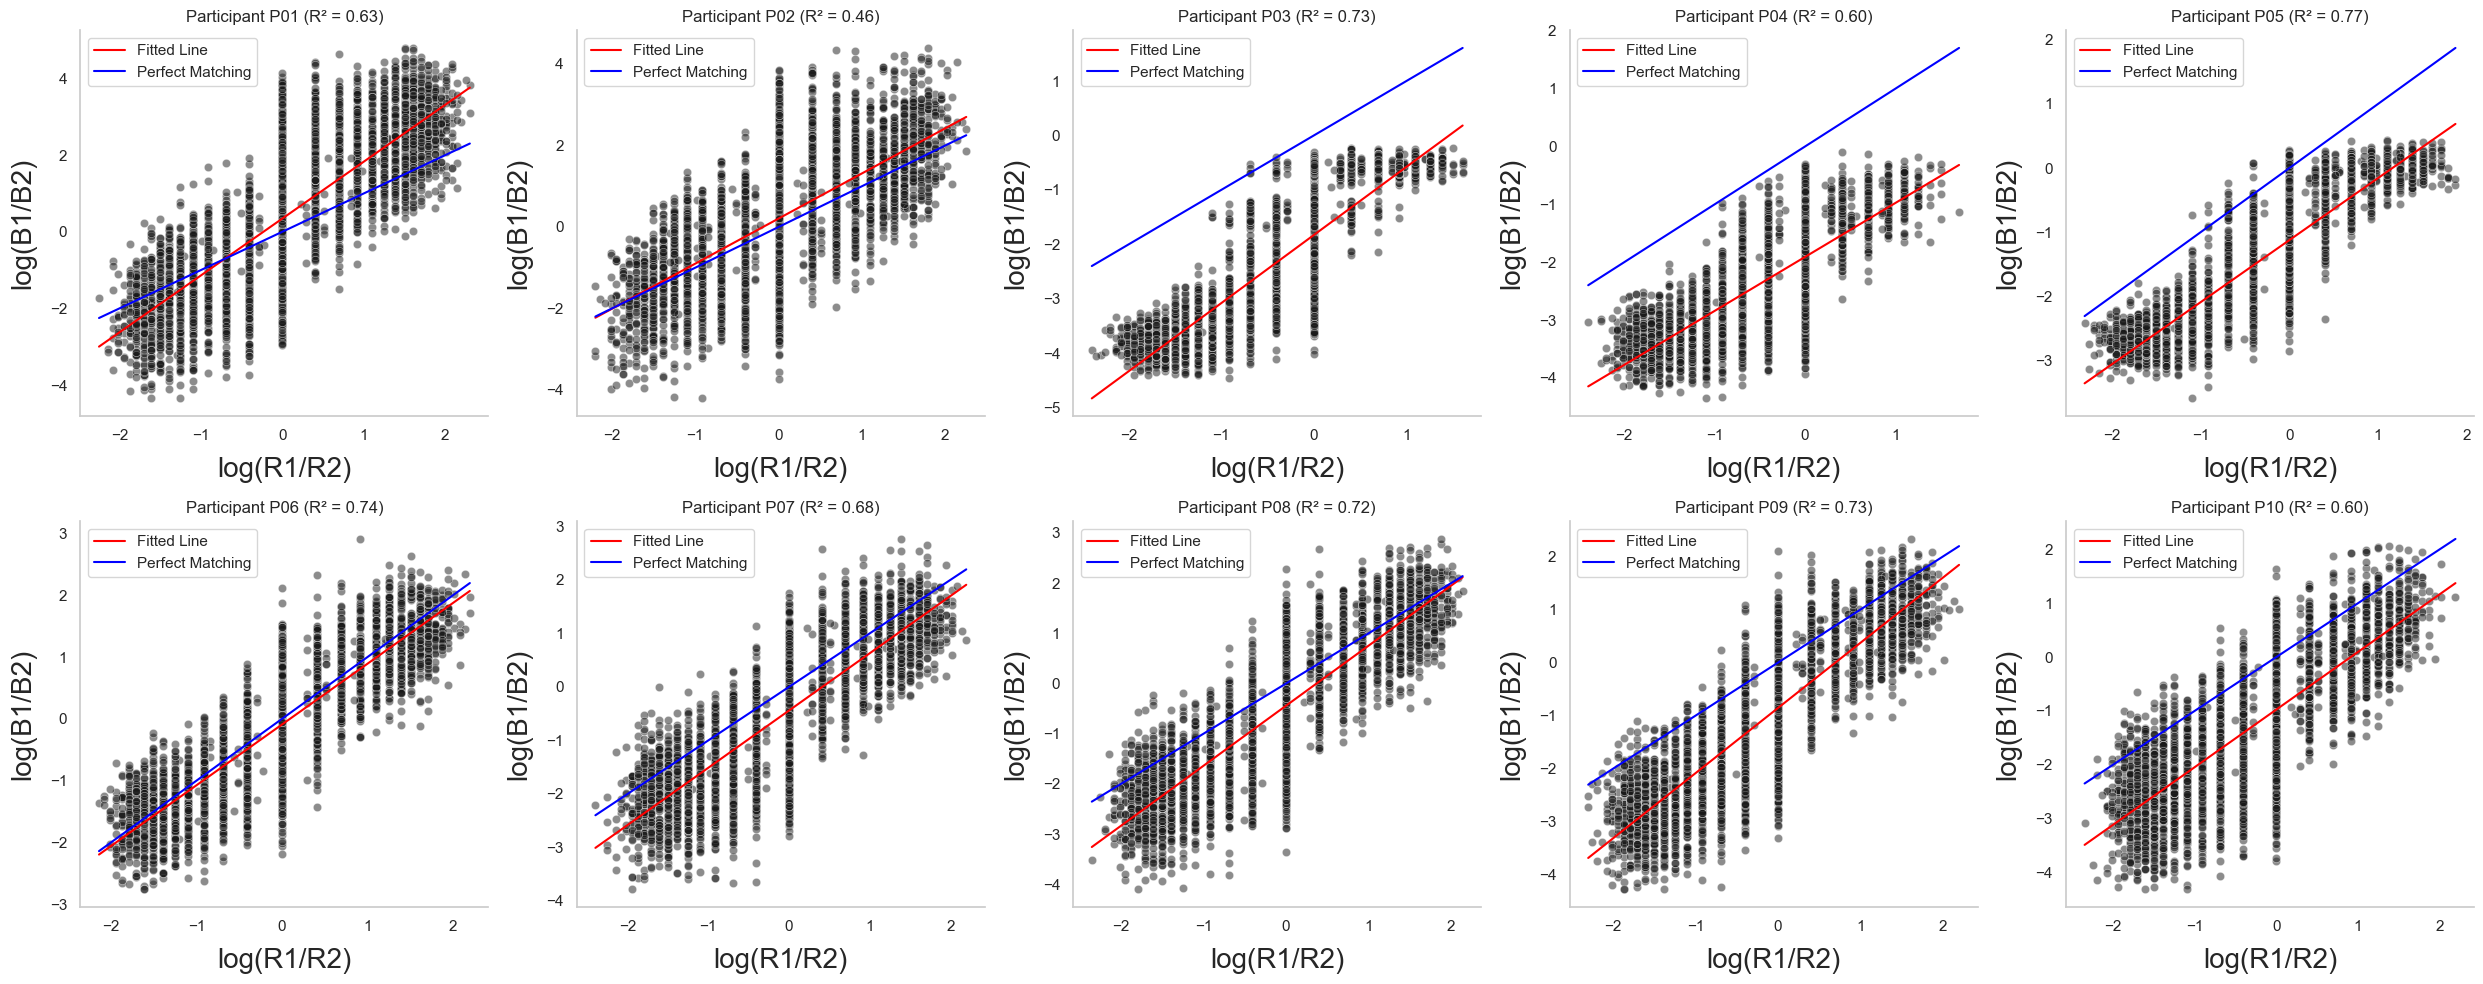

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import numpy as np

results = []
plt.figure(figsize=(25, 10))
participants = all_data['PID'].unique()

for idx, pid in enumerate(participants, 1):
    df = all_data[all_data['PID'] == pid]
    # Remove rows with -inf/inf/nan (from log(0))
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['log_response_ratio', 'log_reinforcer_ratio'])
    
    slope, intercept, r_value, p_value, std_err = linregress(df['log_reinforcer_ratio'], df['log_response_ratio'])
    results.append({
        "Participant": pid,
        "Sensitivity (a)": slope,
        "Bias (log b)": intercept,
        "R-squared": r_value**2
    })
    
    plt.subplot(2, 5, idx)
    sns.scatterplot(x='log_reinforcer_ratio', y='log_response_ratio', data=df, color='k', alpha=0.5)
    x_vals = np.linspace(df['log_reinforcer_ratio'].min(), df['log_reinforcer_ratio'].max(), 100)
    plt.plot(x_vals, slope * x_vals + intercept, color='red', label='Fitted Line')
    plt.plot(x_vals, x_vals, color='blue', label='Perfect Matching')
    plt.title(f'Participant {pid} (R² = {r_value**2:.2f})')
    plt.grid(False)
    plt.xlabel('log(R1/R2)', fontsize=20, labelpad=10)
    plt.ylabel('log(B1/B2)', fontsize=20, labelpad=10)
    sns.despine(top=True, right=True)
    plt.legend()

plt.tight_layout()
plt.show()

<Figure size 2500x600 with 0 Axes>

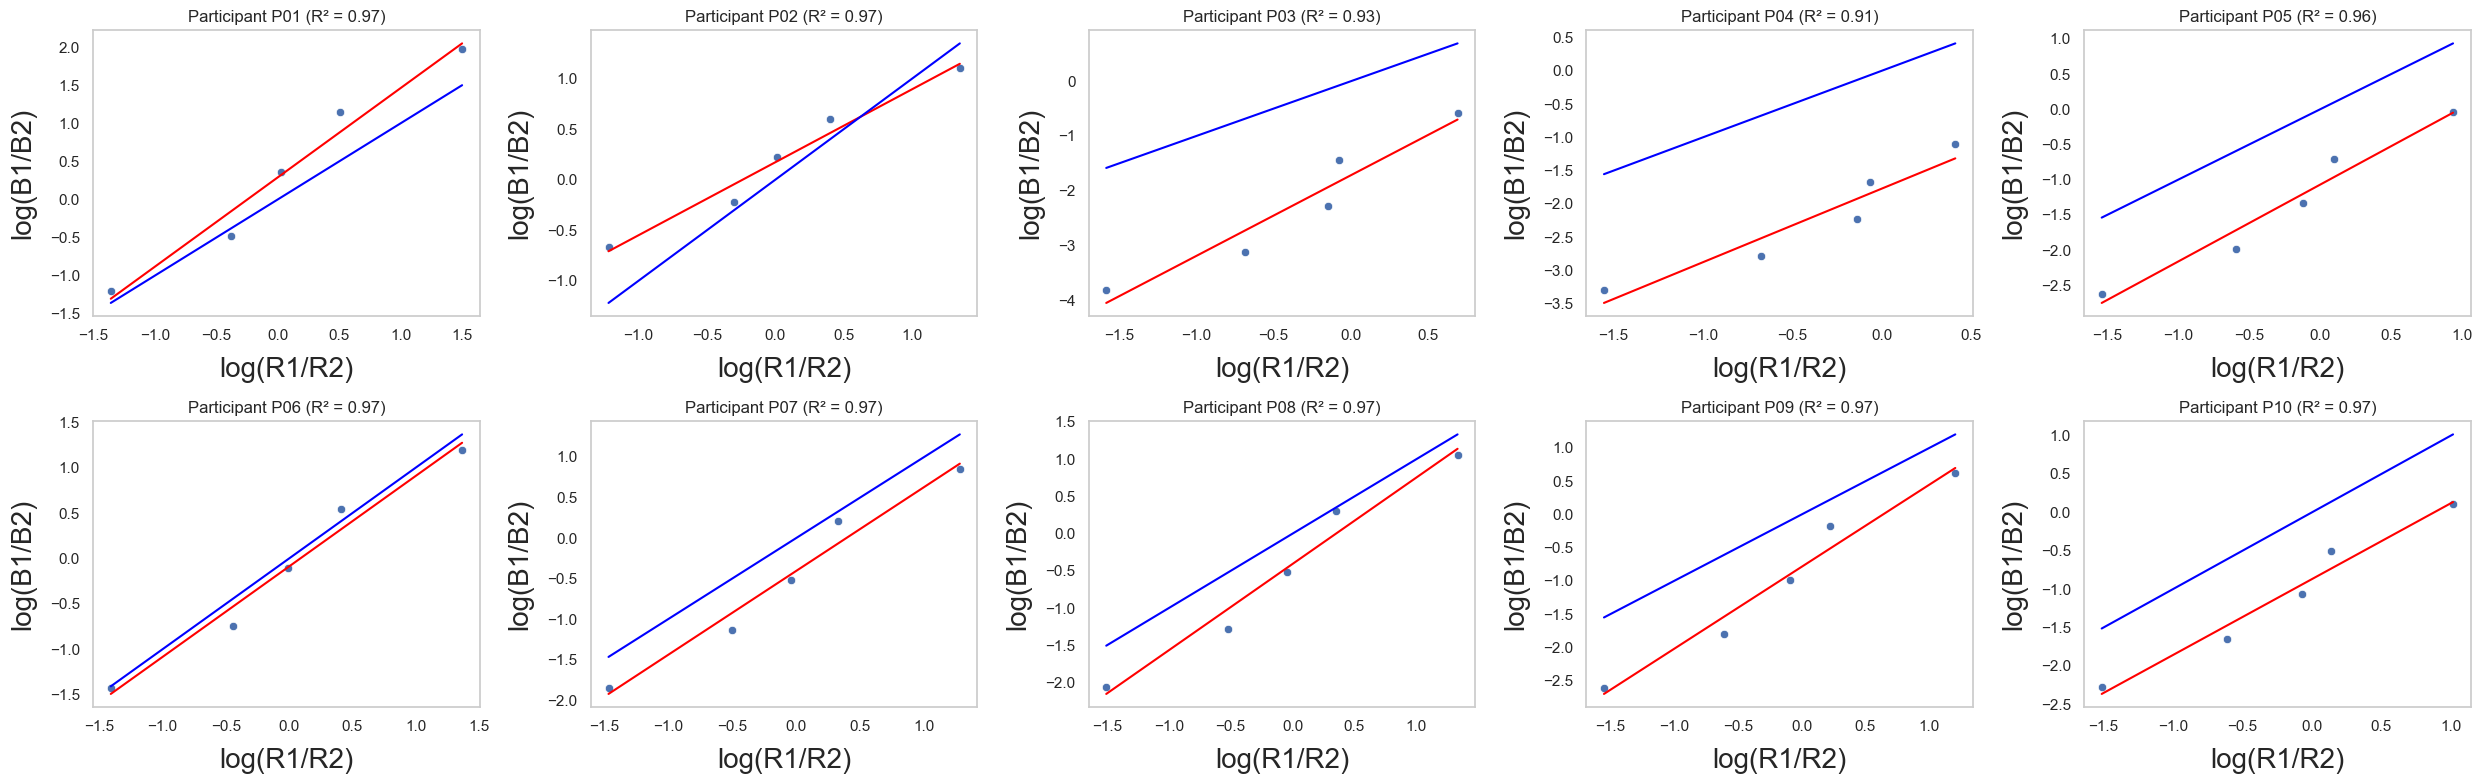

In [57]:
# Calculate mean ratios for each participant and condition
grouped = all_data.groupby(['PID', 'condition']).agg({
    'b1': 'mean',
    'b2': 'mean',
    'r1': 'mean',
    'r2': 'mean'
}).reset_index()

# Calculate log ratios
grouped['log_response_ratio'] = np.log(grouped['b1'] / grouped['b2'])
grouped['log_reinforcer_ratio'] = np.log(grouped['r1'] / grouped['r2'])

results = []
plt.figure(figsize=(25, 6))
participants = grouped['PID'].unique()

results = []
plt.figure(figsize=(25, 8))  # Wider for 10 plots

participants = grouped['PID'].unique()

for idx, pid in enumerate(participants, 1):
    df = grouped[grouped['PID'] == pid]
    # Remove rows with -inf/inf/nan (from log(0))
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['log_response_ratio', 'log_reinforcer_ratio'])
    
    slope, intercept, r_value, p_value, std_err = linregress(df['log_reinforcer_ratio'], df['log_response_ratio'])
    results.append({
        "Participant": pid,
        "Sensitivity (a)": slope,
        "Bias (log b)": intercept,
        "R-squared": r_value**2
    })
    
    plt.subplot(2, 5, idx)  # 2 rows, 5 columns
    sns.scatterplot(x='log_reinforcer_ratio', y='log_response_ratio', data=df)
    x_vals = np.linspace(df['log_reinforcer_ratio'].min(), df['log_reinforcer_ratio'].max(), 100)
    plt.plot(x_vals, slope * x_vals + intercept, color='red', label='Fitted Line')
    plt.plot(x_vals, x_vals, color='blue', label='Perfect Matching')
    plt.title(f'Participant {pid} (R² = {r_value**2:.2f})')
    plt.xlabel('log(R1/R2)', fontsize=20, labelpad=10)
    plt.ylabel('log(B1/B2)', fontsize=20, labelpad=10)
    plt.grid(False)
 
plt.tight_layout()
plt.show()

In [58]:

summary_df = pd.DataFrame(results).sort_values("Participant")
summary_df.reset_index(drop=True, inplace=True)
summary_df


,Participant,Sensitivity (a),Bias (log b),R-squared
0,P01,1.172743,0.289846,0.969271
1,P02,0.722307,0.172703,0.972783
2,P03,1.472491,-1.717408,0.927991
3,P04,1.105456,-1.770987,0.908766
4,P05,1.092111,-1.069491,0.957321
5,P06,0.996862,-0.087968,0.974722
6,P07,1.034862,-0.405765,0.969967
7,P08,1.160194,-0.407012,0.969220
8,P09,1.234320,-0.786963,0.968703
9,P10,0.988644,-0.869895,0.968638


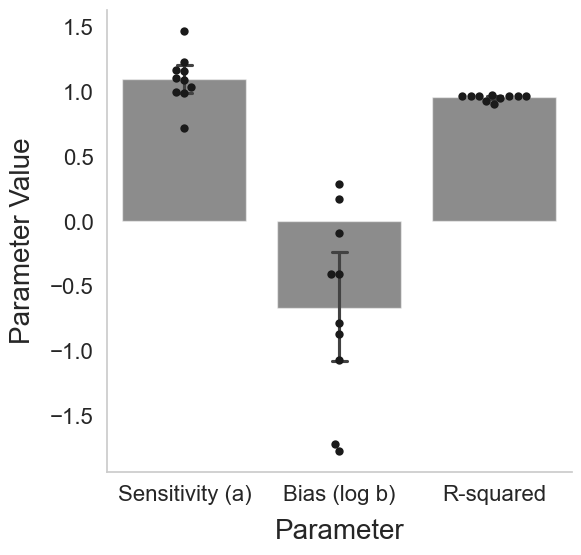

In [59]:
summary_df_long = summary_df.melt(id_vars=['Participant'], var_name='Parameter', value_name='Value')
summary_df_long

# Create a bar plot of the parameters
plt.figure(figsize=(6, 6))
sns.barplot(x='Parameter', y='Value', data=summary_df_long, color='k', alpha=0.5, capsize=0.1)
sns.swarmplot(x='Parameter', y='Value', data=summary_df_long, color='k', size=6)
plt.xlabel('Parameter', fontsize=20, labelpad=10)
plt.ylabel('Parameter Value', fontsize=20, labelpad=10)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(False)
sns.despine(top=True, right=True)
plt.show()